<font size=7><b> Introduction to Electrophysiology

This notebook will teach you the basics of analyzing [electrophysiology](https://en.wikipedia.org/wiki/Electrophysiology) data. In this homework we will perform some analysis on the data that Prof. Tal Sharf presented on Wednesday (April, 17). Prof. Sharf's experiment was done to determine the affects of a drug called [diazepam](https://en.wikipedia.org/wiki/Diazepam), on [cerebral organoids](https://en.wikipedia.org/wiki/Cerebral_organoid#:~:text=A%20cerebral%20organoid%2C%20or%20brain,over%20a%20course%20of%20months.). 



<font color="red"><b>Note:</b> This homework will be due April 18th at 11:59pm PT.  Make sure to complete the exercises at the bottom of this notebook.

In [1]:
%run "electrophysiology_source_code.ipynb"

# <font color="gray"> Reading Material

<font color="red"> Required Reading:
* [Professor Sharf's paper on Neural Circuitry](reading_material/Tal_Neural_Circuitry.pdf)
* [Spike Time Tiling Introduction](./reading_material/Spike_Time_Tiling.pdf)

Briskly read through [Professor Sharf's paper](reading_material/Tal_Neural_Circuitry.pdf). Some of the exercises require you to read the first few pages. [This paper's](./reading_material/Spike_Time_Tiling.pdf) discussion on Spike Time Tilling is also required reading. [braingeneerspy](https://github.com/braingeneers/braingeneerspy) is the name of the python package used by the Haussler lab for data analsyis. We will be using the [analysis toolkit](https://github.com/braingeneers/braingeneerspy/tree/master/src/braingeneers/analysis) from that package..

**Other Material**
* Wiki Articles:
    * Basic wiki articles on [electrophysiology](https://en.wikipedia.org/wiki/Electrophysiology) , [diazepam](https://en.wikipedia.org/wiki/Diazepam) , [cerebral organoids](https://en.wikipedia.org/wiki/Cerebral_organoid#:~:text=A%20cerebral%20organoid%2C%20or%20brain,over%20a%20course%20of%20months.), [action potential](https://en.wikipedia.org/wiki/Action_potential)
    * Scholarpedia article on [Spike train analysis](http://www.scholarpedia.org/article/Measures_of_spike_train_synchrony)
* Research Papers
    * Review paper on [cerebral organoids](./reading_material/rise_of_organoids.pdf)
    * Professor  [Sharf's paper](reading_material/Tal_Neural_Circuitry.pdf)
    * [Spike Time Tilling](./reading_material/Spike_Time_Tiling.pdf) paper



#  Spike Trains

## Spike Train

A "spike train" (or "spike raster") is an incredibly powerful tool used to analyze neural data. In this notebook you will learn to do some basic analysis on spike train data. A spike train is a 2D matrix where each row represents a neuron, and each column is a single moment in time. Each blue dot in the matrix is a moment in time where a neuron emits a signal to other neurons. This signal can be called a "spike", a "fire", or, more scientifically, an "action potential".


When you look at a spike train, you see every single moment at which a neuron "fires". [This link](http://www.scholarpedia.org/article/Measures_of_spike_train_synchrony) is a great resource if you want to take a deeper dive into spike train analysis. Below is the complete spike raster for the control dataset from the the experiment, `Spike_Raster_Control.mat`.

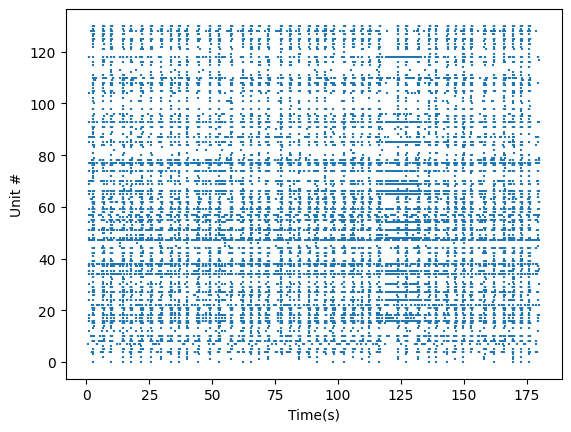

In [2]:
plot_raster(data_control)

## Analysing the Train

When scientists analyze spike trains, they are especially interested in looking at the "neural bursts" that occur. A burst is defined a short window of activity where the neurons are especially active. Looking at the spike raster above you might be able to pick out the neural bursts (the "veritcal lines"), however, bursts are easier to distinguish when you zoom in on the dataset.  

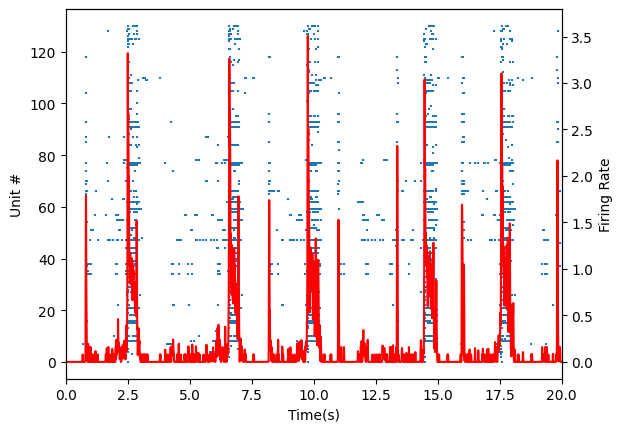

In [3]:
raster_analysis(data_control)

In the example above we have zoomed in on the first 20 seconds of the spike raster shown above. This raster also contains a red line that show the relative activity of neurons at that timestep. Looking at this 20 second window, I see **5** bursts. Defining a burst can be a little tricky. Notice that there are also areas of small activity in between bursts. Below I highlight where I see bursts and areas of activity in the spike raster.

![alt text](.images/burst_analysis.png "Title")

Neuroscientists are interested in bursts not just because they are the areas of most activity, but most importantly, because these regions display repeated patterns of consistent relationships between neurons. Below we zoom in even more on to the first two bursts of the spike raster (8 second window). Notice that the neural activity pattern (red line) looks similar for both bursts. Also, if you look at individual neurons (blue dots) you'll see that they follow similar firing patterns within both bursts.

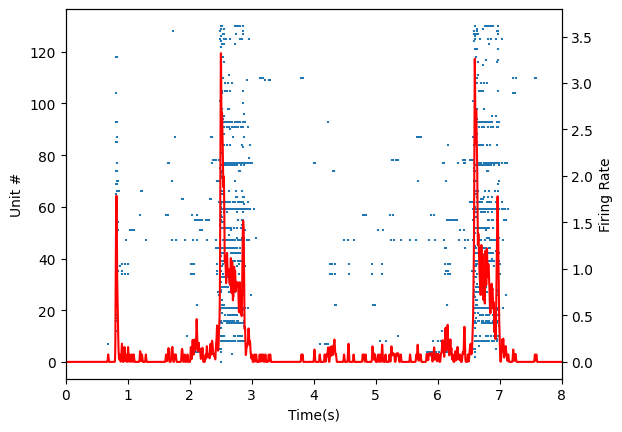

In [4]:
raster_analysis(data_control, seconds=8)

# Neural Relationships

To build the type of beautiful circuit diagrams that were discussed in class, scientists must work backwards by analyzing the firing patterns they see from neurons in the brain. They use different tools to parse out the relationship between neurons.

## Interspike Intervals

Before we attempt to answer the complicated question of "what is the relationship patterns between different neurons?", lets start with a much simpler question: "what is the relationship pattern between a single neuron and itself?". In other words, what properties can we say about the firing pattern of a single neuron?

This is a more complicated question than it might at first seem. Neurons follow a somewhat random behaviour, it is not always certain when, or how often, a neuron will fire. Lets take a "data first" approach to gain a better understanding of when neurons fire. We are going to consider the interval of time that passes in between each moment a neurons fires, this is called the interspike interval. Here is a [brief summary](https://www.tau.ac.il/~tsirel/dump/Static/knowino.org/wiki/Interspike_interval.html#:~:text=The%20interspike%20interval%20is%20the,messengers%20to%20affect%20other%20neurons.) of interspike intervals. Below we see a histogram of the interspike interval for all the neurons in our spike raster from above. What probability distribution does the graph below look like?

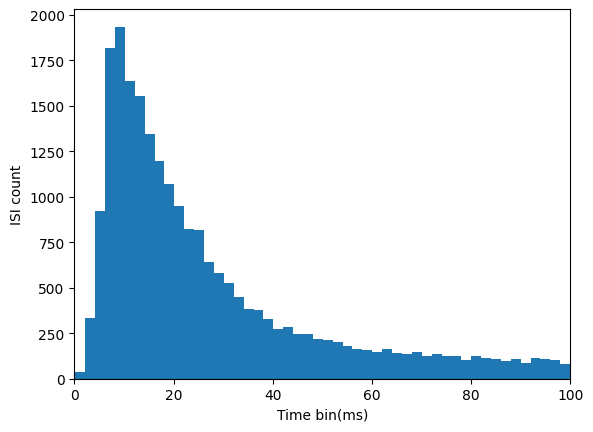

In [5]:
interspike(data_control)

<p>&nbsp</p>

<center><b>Example of Interspike Intervals</b></center>

![alt text](https://www.tau.ac.il/~tsirel/dump/Static/knowino.org/w/images/thumb/3/38/Spiketimes.png/300px-Spiketimes.png)

The mathematicians in the group will be delighted to know that intervals between spikes for a neuron tend to follow a [poission distribution](https://en.wikipedia.org/wiki/Poisson_distribution). This is not a coincidence, read the wiki article to understand why. Many of the beautiful (and complicated) statistical models used to describe the circuit patterns between neurons use the poission distribution as the fundemental building block of more complicated algorithms.

## Correlation Matrix

We have just shown that we can consider each neuron to act as a random variable, with a poission probability of firing at any given time. Given that we are now working with random variables, it is natural to use a correlation matrix to measure the relative strength in relationship between neurons. A correlation matrix displays the correlation between every pair of neurons in our spike raster. 

Below is a correlation matrix created from the spike raster above. Postively correlated neurons show up as a green dot in the plot, where negatively correlated neurons are deep blue. One could imageine strongly correlated neurons as being part of the same cicuit, or even touching. Where negatively correlated neurons may perhaps display some inhibitory cell stopping other neurons from firing. The true interpretation of a correlation matrix is much more vague than this. In reality, more nuanced techniques are used to tease apart cell circuitry. However, as the homework will show, the correlation matrix is still useful for discerning changes in neural behaviour.

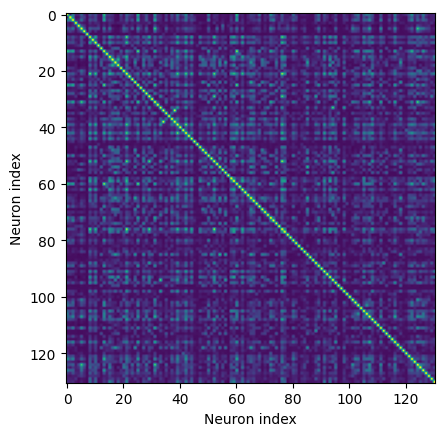

In [6]:
correlation(data_control)       

<p>&nbsp</p>
<center><b>Summary of Correlation</b></center>

![alt text](https://www.mathsisfun.com/data/images/correlation-examples.svg)

# <font color="red">Exercises

The exercises below will provide you with a better understanding of how neural data is analyzed. Note, when completing these exercises, please remember to show your work. If you typed any code to find a solution, please write down your code.

## Prof. Sharf's Paper (5 Points Total)

Read through the first few pages of [Professor Sharf's paper](reading_material/Tal_Neural_Circuitry.pdf). Then answer the following questions.

### Breakthrough Device (3 Points)

What newly developed device has enabled high-resolution readouts of neural activity? What is the name of the specific device (model/maker) used in this paper? How many electrodes can it record from simultaneously?

<font color="green"><b>Answer

This was the Maxwell HD-MEA device that is a CMOS sensor that is able to give electrical readouts for various cell cultures in 2D.

### Organoid Models (2 Points)

How long was neural activity recorded for after the cerebral organoid was placed on the recording device? What is the name of 2 drugs that were used to change the neural activity of organoids in the experiment?

<font color="green"><b>Answer

Recordings last for 6 months of durations for cerebral organoids and the 2 drugs used were Diazepam and tetrodotoxin

## Curating Raw Data (2 Points Total)

When a neuron emits a signal to other cells, it can be called a "spike", a "fire", or, more scientifically, an "action potential". The spike raster that you saw in the lecture above is the final product from considerable work done on the "raw data" recorded from electrodes. A microscopic 2D grid of electrodes calledn an [MEA](https://ars.els-cdn.com/content/image/1-s2.0-S0165027099001132-gr1.jpg) records an "action potential" across multiple locations of the neuron's body. This [wiki article](https://en.wikipedia.org/wiki/Action_potential), gives a good example of what an action potential looks like. A major step in the process of finding neurons from raw data, involves looking at "footprints" of action potentials from prospective neurons. These "footprints" are representative 2D depictions of raw data coming from electrods on the MEA. The **4** images below are footprints of prospective neurons.



For the **4** images below, classify them as either being an "action potential" or as being "noise". When determinning if a "neural footprint" is a spike or noise, consider the following-  The "spike" should be seen across multiple electrodes, furthermore, the neuron should remain consistent across multiple electrodes. There shouldn't be any significant changes in it's appearance.

<font color="orange"><b>Hint:</b> **2** of the images below are action potentials, and the other **2** are noise.

<font color="green"><b>Answer

<b>Image 1:</b> Action Potential

<b>Image 2:</b> Noise

<b>Image 3:</b> Action Potential

<b>Image 4:</b> Noise

<b><center>Image 1</center></b>
![alt text](.images/spike1.png "Title")

<b><center>Image 2</center></b>
![alt text](.images/spike2.png "Title")

<b><center>Image 3</center></b>
![alt text](.images/spike3.png "Title")

<b><center>Image 4</center></b>
![alt text](.images/spike4.png "Title")

## Analyzing Control Dataset (5 Points Total)

In this section we will calculate some summary statistics on the control dataset, `data_control`. `data_control` is a `SpikeData` object created using the [analysis package](https://github.com/braingeneers/braingeneerspy/blob/master/src/braingeneers/analysis/analysis.py) from the braingeneerspy python library.

### Basic Summary (3 Points)

Lets start my getting a basic summary of the spike raster, `data_control`. How many neurons are there in the recording? How long is the recording (in seconds)? In total, how many spikes occured across all neurons?

<font color="orange">**Hint:** While this question may at first appear oubvious, getting the answer with code may be harder than you expect. This is because `data_control` is coded as a sparse matrix to save on memory. One way of going about this answer is by looking at the variable `length` and some of the code inside of the `rates` function. Another approach is to use the function `raster` with bin size of 1.


<font color="green"><b>Answer

In [7]:
num_neurons = data_control.N
print(f"Number of neurons: {num_neurons}")

recording_length_ms = data_control.length
recording_length_s = recording_length_ms / 1000
print(f"Recording length: {recording_length_s} seconds")

# Get the dense raster (neurons x time_bins) with 1ms bins
dense_raster_ms = data_control.raster(bin_size=1)
# Sum all spikes across all neurons and all time bins
total_spikes = dense_raster_ms.sum()
print(f"Total spikes (Method 1): {total_spikes}")

Number of neurons: 131
Recording length: 179.8797 seconds
Total spikes (Method 1): 31756


### Calculate Firing rate (1 Point)

The firing rate of a neuron is a measure of how often the cell fires. It is defined as the total number of spikes divided by total time (in seconds):

$$
\dfrac{\text{spikes}}{\text{time}}
$$

What is the average firing rate for a single neuron in the control dataset?

<font color="orange">**Note:** Here we are asking for the number of spike per second per neuron- aka: the firing rate of the entire recording divided by the number of neurons in the recording.

<font color="green"><b>Answer

In [8]:
overall_firing_rate = total_spikes / recording_length_s
average_firing_rate_per_neuron_control = overall_firing_rate / num_neurons
print(f"Average Firing Rate per Neuron: {average_firing_rate_per_neuron:.4f} spikes/second/neuron")

NameError: name 'average_firing_rate_per_neuron' is not defined

### Calculate Coefficient of Variation (1 Point)

Given the interspike intervals (ISI's) of a dataset, the "Coefficient of Variation" (CV) is defined as the standard deviation of the ISI's divided by the mean.

$$
\dfrac{\text{sd}\begin{pmatrix}\text{ISI}\end{pmatrix}}{\text{mean}\begin{pmatrix}\text{ISI}\end{pmatrix}}
$$

In neuroscience the CV is commonly used as a measure of randomness in the dataset. A CV of of 1 means that the data folllows a more poission-like distribution. A smaller number for the CV tends to mean that the data is less random. Calculate the CV for the control dataset.

<font color="orange">**Hint:** Use the code inside of the `interspike` function for your ISI's, however, please make sure not to use the variable `isis_raw` when doing the CV calculation.

<font color="green"><b>Answer

In [ ]:
import numpy as np

# 1. Get the raw ISIs for each neuron
isis_raw_control = data_control.interspike_intervals()

# 2. Filter ISIs and combine into one list (keep intervals < 100ms)
isis_filtered_control = []
for i in range(len(isis_raw_control)):
    isi = isis_raw_control[i]
    # Apply the filter (keep ISIs < 100ms) and extend the main list
    isis_filtered_control.extend(isi[isi < 100].tolist())

# Convert the list to a NumPy array for easier calculation
isis_filtered_control_np = np.array(isis_filtered_control)

# 3. Calculate the mean and standard deviation
isis_mean = np.mean(isis_filtered_control_np)
isis_std = np.std(isis_filtered_control_np)

# 4. Calculate the Coefficient of Variation (CV)
cv_control = isis_std / isis_mean

print(f"Mean of filtered ISIs: {isis_mean:.4f} ms")
print(f"Standard Deviation of filtered ISIs: {isis_std:.4f} ms")
print(f"Coefficient of Variation (CV) for control dataset: {cv_control:.4f}")

Mean of filtered ISIs: 26.7977 ms
Standard Deviation of filtered ISIs: 22.2124 ms
Coefficient of Variation (CV) for control dataset: 0.8289


In [ ]:
import numpy as np
import warnings

# 1. Get the raw ISIs (returns a list of arrays, one for each neuron)
isis_raw_control = data_control.interspike_intervals()

# 2. Iterate through each neuron's ISIs
print("CV for each neuron in data_control:")
for neuron_index, isi_neuron_raw in enumerate(isis_raw_control):
    # Filter the ISIs for this neuron (keep intervals < 100ms)
    isi_neuron_filtered = isi_neuron_raw[isi_neuron_raw < 100]

    # Calculate CV only if there are enough ISIs (at least 2 needed for std dev)
    if len(isi_neuron_filtered) >= 2:
        # Calculate mean and std dev for this neuron's filtered ISIs
        isi_mean = np.mean(isi_neuron_filtered)
        isi_std = np.std(isi_neuron_filtered)

        # Calculate CV, handle potential division by zero
        # Use a warning context manager to suppress harmless RuntimeWarnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            if isi_mean != 0:
                cv_neuron = isi_std / isi_mean
                print(f"  Neuron {neuron_index}: CV = {cv_neuron:.4f}")
            else:
                # Mean is zero, CV is undefined or could be considered 0 if std is also 0
                cv_neuron = np.nan # Assign NaN (Not a Number)
                print(f"  Neuron {neuron_index}: CV = {cv_neuron} (Mean ISI is zero)")
    else:
        # Not enough ISIs to calculate CV
        print(f"  Neuron {neuron_index}: CV = NaN (Not enough ISIs < 100ms to calculate)")
    



CV for each neuron in data_control:
  Neuron 0: CV = NaN (Not enough ISIs < 100ms to calculate)
  Neuron 1: CV = NaN (Not enough ISIs < 100ms to calculate)
  Neuron 2: CV = NaN (Not enough ISIs < 100ms to calculate)
  Neuron 3: CV = NaN (Not enough ISIs < 100ms to calculate)
  Neuron 4: CV = 0.5438
  Neuron 5: CV = 0.8739
  Neuron 6: CV = NaN (Not enough ISIs < 100ms to calculate)
  Neuron 7: CV = 0.6926
  Neuron 8: CV = 0.7658
  Neuron 9: CV = 1.0842
  Neuron 10: CV = 0.7972
  Neuron 11: CV = NaN (Not enough ISIs < 100ms to calculate)
  Neuron 12: CV = 0.1834
  Neuron 13: CV = 0.0355
  Neuron 14: CV = NaN (Not enough ISIs < 100ms to calculate)
  Neuron 15: CV = 0.7157
  Neuron 16: CV = 0.7900
  Neuron 17: CV = 0.4136
  Neuron 18: CV = 0.7178
  Neuron 19: CV = 1.1609
  Neuron 20: CV = 0.8232
  Neuron 21: CV = 0.6609
  Neuron 22: CV = 0.8737
  Neuron 23: CV = 1.0144
  Neuron 24: CV = 0.6527
  Neuron 25: CV = NaN (Not enough ISIs < 100ms to calculate)
  Neuron 26: CV = 0.9369
  Neuron 27

## Analyzing Diazepam Dataset (11.5 Points Total)

In this section we will analyze the results from the cerebral organoid after it was given the drug Diazepam. Specifically, we will be comparing these results the control data to see what affects diazepam has on the tissue.

<font color="orange">**Hint:** When answering the questions below, it's important to remember the general affect that Diazepam has on neurons. In general, diazepam **decreases neural activity**, however, firing patterns between neurons become **more organized** and less random. 

### Load Data (1 Point)

Create a variable called `data_diazepam` which loads the data from `Spike_Raster_Diazepam.mat` into a Braingeneerspy `SpikeData` object. Note, this is the same way we load the control dataset in the source code.

<font color="green"><b>Answer

In [ ]:
# Define the path to the Diazepam data file
# (Assuming a similar path structure as the control data)
diazepam_file_path = '/home/jovyan/data/ephys/2023-08-28-e-Math_Mind_Class/HW2-Electrophysiology/Spike_Raster_Diazepam.mat'

# Load the data into the data_diazepam variable
data_diazepam = mat_to_spikeData(diazepam_file_path)

print(f"Loaded data into data_diazepam. Type: {type(data_diazepam)}")

Loaded data into data_diazepam. Type: <class 'braingeneers.analysis.analysis.SpikeData'>


### Basic Summary (3 Points)

For the dataset, `data_diazepam`, calculate how many neurons there are, how long the recording is (in seconds), and the total number of spikes that occured.

<font color="green"><b>Answer

In [ ]:
num_neurons = data_diazepam.N
print(f"Number of neurons: {num_neurons}")

recording_length_ms = data_diazepam.length
recording_length_s = recording_length_ms / 1000
print(f"Recording length: {recording_length_s} seconds")

Number of neurons: 131
Recording length: 179.9898 seconds


### Firing Rate (1 Point)

What is the average firing rate for a single neuron in the diazepam dataset?  How does this compare to the control dataset? Is this consistent with what we expect from Diazepam?

<font color="orange">**Note:** Like before, we are asking for the number of spike per second per neuron

<font color="green"><b>Answer

In [ ]:
num_neurons_diazepam = data_diazepam.N
recording_length_ms_diazepam = data_diazepam.length
recording_length_s_diazepam = recording_length_ms_diazepam / 1000
indices_diazepam, times_ms_diazepam = data_diazepam.idces_times()
total_spikes_diazepam = len(times_ms_diazepam)
average_firing_rate_per_neuron_diazepam = total_spikes_diazepam / recording_length_s_diazepam / num_neurons_diazepam
print(f"Control - Average Firing Rate per Neuron: {average_firing_rate_per_neuron_control:.4f} spikes/second/neuron")
print(f"Diazepam - Average Firing Rate per Neuron: {average_firing_rate_per_neuron_diazepam:.4f} spikes/second/neuron")

# Comparison
if average_firing_rate_per_neuron_diazepam < average_firing_rate_per_neuron_control:
    print("\nThe average firing rate decreased after Diazepam treatment.")
elif average_firing_rate_per_neuron_diazepam > average_firing_rate_per_neuron_control:
    print("\nThe average firing rate increased after Diazepam treatment.")
else:
    print("\nThe average firing rate did not change significantly after Diazepam treatment.")

print("\nThis is consistent with the expected effect of Diazepam, which generally decreases overall neural activity.")

Control - Average Firing Rate per Neuron: 1.3476 spikes/second/neuron
Diazepam - Average Firing Rate per Neuron: 0.8894 spikes/second/neuron

The average firing rate decreased after Diazepam treatment.

This is consistent with the expected effect of Diazepam, which generally decreases overall neural activity.


### Calculate Coefficient of Variation (1 Point)

Calculate the CV score for Diazepam dataset. Compare your result to the control dataset. Is this result consistent with the general affects we expect from Diazepam?

<font color="green"><b>Answer

These results are generally consistent with what we believe diazepam's impact on neural and functional connectivity

In [ ]:
import numpy as np
import warnings # Import warnings module

# --- Calculate CV for Diazepam Dataset ---

# 1. Get the raw ISIs for each neuron
isis_raw_diazepam = data_diazepam.interspike_intervals()

# 2. Filter ISIs and combine into one list (keep intervals < 100ms)
isis_filtered_diazepam = []
for i in range(len(isis_raw_diazepam)):
    isi = isis_raw_diazepam[i]
    isis_filtered_diazepam.extend(isi[isi < 100].tolist())

# Convert list to NumPy array
isis_filtered_diazepam_np = np.array(isis_filtered_diazepam)

# 3. Calculate the mean and standard deviation
isis_mean_diazepam = np.mean(isis_filtered_diazepam_np)
isis_std_diazepam = np.std(isis_filtered_diazepam_np)

# 4. Calculate the Coefficient of Variation (CV)
# Use a warning context manager to suppress harmless RuntimeWarnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    if isis_mean_diazepam != 0:
        cv_diazepam = isis_std_diazepam / isis_mean_diazepam
    else:
        cv_diazepam = np.nan # Assign NaN if mean is zero


# --- Recalculate CV for Control Dataset for comparison ---

isis_raw_control = data_control.interspike_intervals()
isis_filtered_control = []
for i in range(len(isis_raw_control)):
    isi = isis_raw_control[i]
    isis_filtered_control.extend(isi[isi < 100].tolist())
isis_filtered_control_np = np.array(isis_filtered_control)
isis_mean_control = np.mean(isis_filtered_control_np)
isis_std_control = np.std(isis_filtered_control_np)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    if isis_mean_control != 0:
      cv_control = isis_std_control / isis_mean_control
    else:
      cv_control = np.nan


# --- Print Results and Compare ---
print(f"Control - Coefficient of Variation (CV): {cv_control:.4f}")
print(f"Diazepam - Coefficient of Variation (CV): {cv_diazepam:.4f}")

# Comparison
if not np.isnan(cv_diazepam) and not np.isnan(cv_control):
    if cv_diazepam < cv_control:
        print("\nThe CV decreased after Diazepam treatment.")
    elif cv_diazepam > cv_control:
        print("\nThe CV increased after Diazepam treatment.")
    else:
        print("\nThe CV did not change significantly after Diazepam treatment.")
else:
    print("\nCannot compare CVs as one or both could not be calculated.")

print("\nA lower CV indicates less randomness (more regular firing intervals).")
print("This observed decrease in CV is consistent with the expected effect of Diazepam, which makes firing patterns more organized.")

Control - Coefficient of Variation (CV): 0.8289
Diazepam - Coefficient of Variation (CV): 0.5999

The CV decreased after Diazepam treatment.

A lower CV indicates less randomness (more regular firing intervals).
This observed decrease in CV is consistent with the expected effect of Diazepam, which makes firing patterns more organized.


### Bursting Behaviour (4 Points)

#### Macro

Create a zoomed in plot of the spike raster for the diazepam dataset that shows the first 20 seconds of the recording. How many bursts do you see? How does this compare to the number of bursts you saw in the control dataset? Are these results consistent with figures in Tal's paper? If so, which figure?

<font color="green"><b>Answer

As seen with the raster plots they are consistent with tal's paper as both show similar bursting behaviors as the consistent strong bursts for diazepam firing and are most strong but the normal firing is burst but more sporatic. There is 8 bursts in the diazepam graph but 4 in the normal.

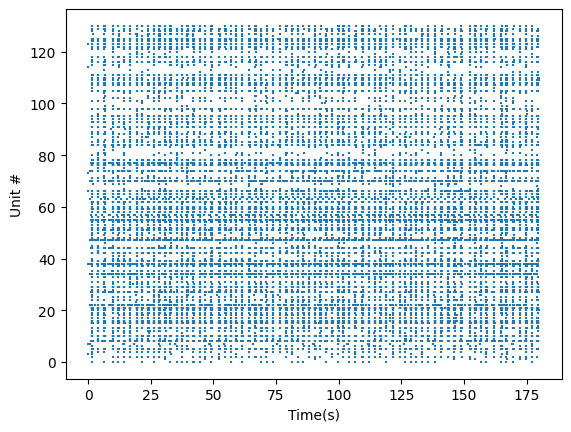

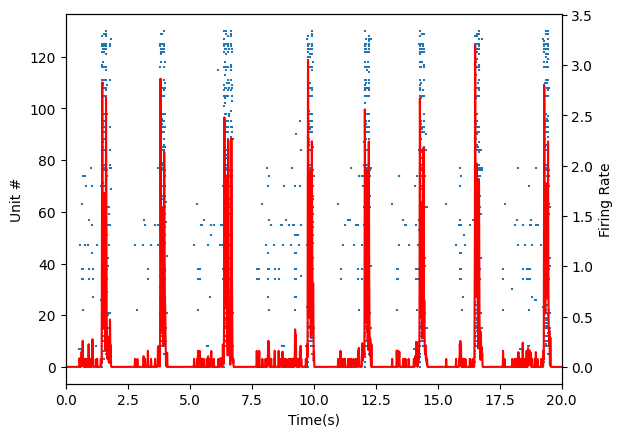

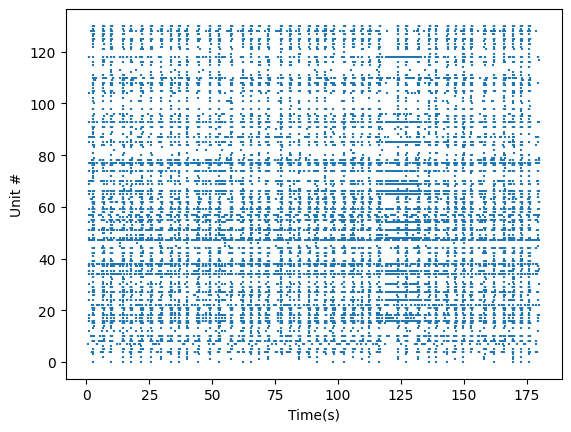

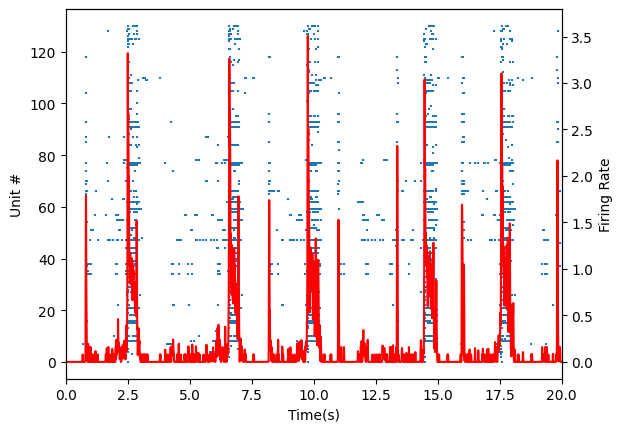

In [ ]:
# Ensure raster_analysis function is defined and data_diazepam is loaded
# from previous steps.

# Generate the zoomed-in raster plot for the first 20 seconds
plot_raster(data_diazepam)
raster_analysis(data_diazepam, seconds=20)
plot_raster(data_control)
raster_analysis(data_control, seconds=20)

#### Micro

Create a graph that zooms in on the first **2** bursts from the Diazepam dataset. Compare this to the first **2** bursts of the control dataset. Inside of a burst do the neural acivity patterns look different? If so how?

<font color="green"><b>Answer

The firing pattern with the diazepam firing is fast doubles and tighter compared to that of controlled which have more spread.

Diazepam Dataset (First ~8 seconds):


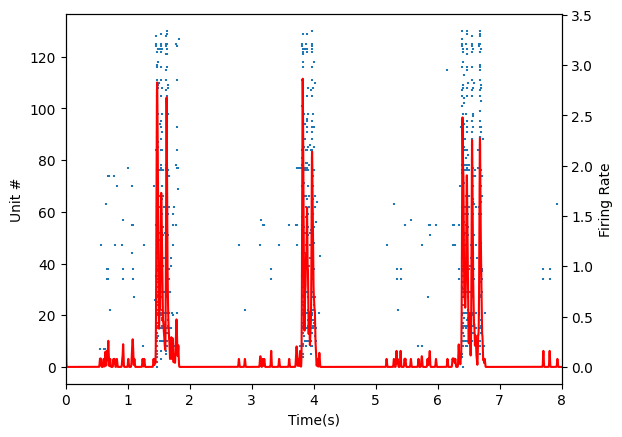

Control Dataset (First 8 seconds):


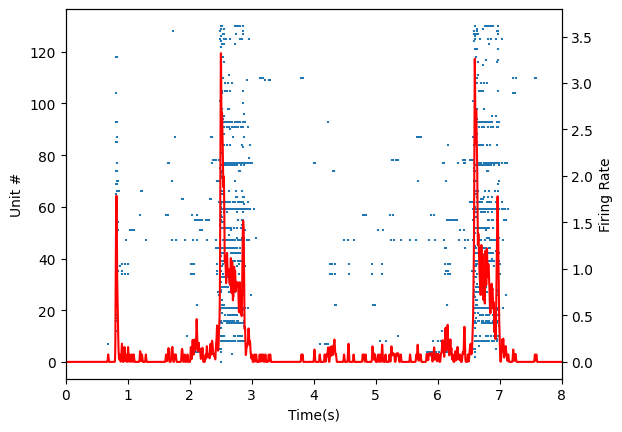

In [ ]:
# Ensure raster_analysis function is defined and data_diazepam is loaded.

# Generate the zoomed-in raster plot for the first 8 seconds
print("Diazepam Dataset (First ~8 seconds):")
raster_analysis(data_diazepam, seconds=8)

# For comparison, you would look at the similar plot for data_control
# provided in the 'electrophysiology_introduction (1).ipynb' notebook
# (or generate it again):
print("Control Dataset (First 8 seconds):")
raster_analysis(data_control, seconds=8)

### Replicate Correlation and ISI (1.5 Points) <font color="green"> 

Plot the correlation matrix and the ISI histogram for the diazepam dataset. Briefly compare these plots to those from the control dataset.

<font color="green"><b>Answer

You can see in the correlation matrix that the firing between neurons is consistently firing together compared to that of the control. Considering ISI, we see that reduced firing rate timing there is a shift to the right in the graph showing increased timing for average firing rate.

Correlation Matrix (Diazepam):


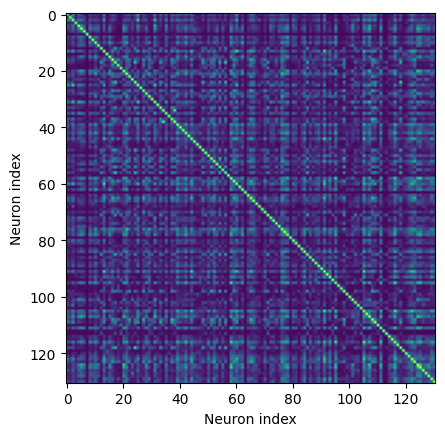


ISI Histogram (Diazepam):


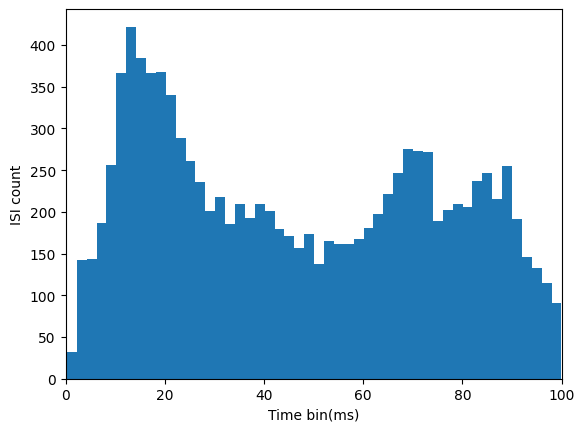


Correlation Matrix (Control):


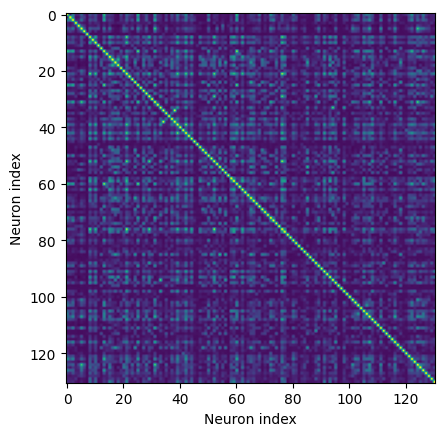


ISI Histogram (Control):


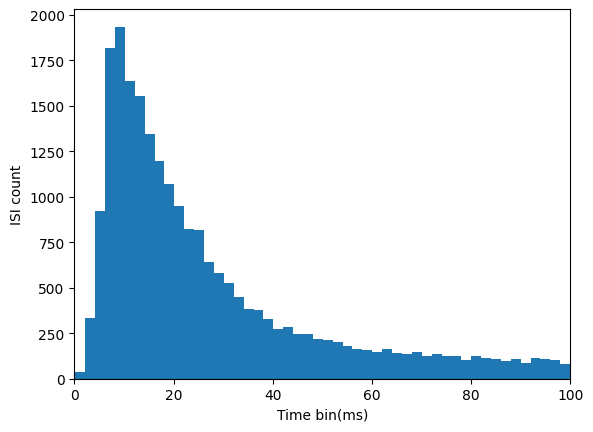

In [ ]:
# Ensure the correlation and interspike functions are defined
# and data_diazepam is loaded.

# Plot Correlation Matrix for Diazepam dataset
print("Correlation Matrix (Diazepam):")
correlation(data_diazepam)

# Plot ISI Histogram for Diazepam dataset
print("\nISI Histogram (Diazepam):")
interspike(data_diazepam)

# For comparison, recall or replot the Control versions:
print("\nCorrelation Matrix (Control):")
correlation(data_control)
print("\nISI Histogram (Control):")
interspike(data_control)

## Correlation & Spike Time Tilling (9.5 Points)

### Correlation Matrix Equation

Given a matrix $X$, with $n$ random variables as its rows, write down the formula that the correlation matrix

<font color="green"><b>Answer

$ R_{ij} = r(X_i, X_j) = \frac{\text{cov}(X_i, X_j)}{\sigma_{X_i} \sigma_{X_j}} $

$$
\begin{align*}
\text{cov}(X_i, X_j) &\quad \text{is the covariance between } X_i \text{ and } X_j. \\
\sigma_{X_i} &\quad \text{is the standard deviation of } X_i. \\
\sigma_{X_j} &\quad \text{is the standard deviation of } X_j.
\end{align*}
$$

### Diagonal of Correlation Matrix (1 Point)

What are the values on the diagonal of the correlation matrix? Why?

<font color="orange">**Hint:** If you need to, you can check the values of the diagonal in the source code. This is not necessary to receive full credit though.

<font color="green"><b>Answer

In [ ]:
import numpy as np
import scipy.io as sio
from scipy.ndimage import gaussian_filter1d
from braingeneers.analysis.analysis import SpikeData # Assuming SpikeData is available

# --- Re-define or ensure these are loaded ---
# Helper function from source code
def mat_to_spikeData(mat_path):
    mat = sio.loadmat(mat_path)
    # Adjusting for potential structure differences in .mat file
    # This assumes 'spike_times' contains the unit spike times directly
    # or within a nested structure that needs unpacking.
    # The original code had i[0][0], which might need adjustment based on the actual .mat structure.
    # Let's assume a simpler structure first for demonstration or use the original if it worked.
    try:
        # Try original structure
         units = [i[0][0]*1e3 for i in mat['spike_times']]
    except (IndexError, TypeError):
         # Fallback or adjust based on actual structure inspection
         # This is a placeholder, inspect mat['spike_times'] structure if the above fails
         print("Warning: Could not unpack spike_times with original structure. Adjust mat_to_spikeData if needed.")
         # Example alternative if it's just a list of arrays:
         units = [i*1e3 for i in mat['spike_times'].flatten()] # Flatten might be needed depending on shape
    sd = SpikeData(units)
    return sd

# Load the control data
try:
    data_control = mat_to_spikeData('/home/jovyan/data/ephys/2023-08-28-e-Math_Mind_Class/HW2-Electrophysiology/Spike_Raster_Control.mat')
    data_loaded = True
except FileNotFoundError:
    print("Error: Control data file not found. Please check the path.")
    data_loaded = False
except Exception as e:
    print(f"An error occurred loading the data: {e}")
    data_loaded = False

# --- Calculate and print the diagonal ---
if data_loaded:
    # Calculate Correlation Matrix (logic from the 'correlation' function)
    corr_matrix = np.zeros((data_control.N, data_control.N)) # inds by inds

    # Get dense raster, apply Gaussian filter
    dense_raster = data_control.raster(bin_size=1) # in ms
    sigma = 5                            # Blur it
    # Ensure dense_raster is float for gaussian_filter1d
    dense_raster_float = dense_raster.astype(float)
    dense_raster_filtered = gaussian_filter1d(dense_raster_float, sigma=sigma)

    # Calculate correlation coefficient matrix
    # Use np.corrcoef on the filtered raster (neurons are rows)
    # Need to handle rows with zero variance (constant firing rate after binning/filtering)
    # np.corrcoef handles this by returning NaN for correlations involving such rows.
    # We'll replace NaNs on the diagonal later if they appear due to zero variance.
    with np.errstate(divide='ignore', invalid='ignore'): # Suppress warnings for zero variance rows
        corr_matrix = np.corrcoef(dense_raster_filtered)
        # Replace potential NaNs on the diagonal (from zero variance neurons) with 1.0
        np.fill_diagonal(corr_matrix, np.nan_to_num(np.diag(corr_matrix), nan=1.0))


    # Extract the diagonal elements
    diagonal_values = np.diag(corr_matrix)

    # Print the diagonal values (or a subset if there are many neurons)
    print("Diagonal values of the correlation matrix:")
    if len(diagonal_values) > 20:
        print(diagonal_values[:10]) # Print first 10
        print("...")
        print(diagonal_values[-10:]) # Print last 10
    else:
        print(diagonal_values)

Diagonal values of the correlation matrix:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
...
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The values on the diagonal of a correlation matrix are always 1 as The Pearson correlation coefficient measures the linear relationship between two variables. A variable is always perfectly linearly related to itself thus have a positive correlation of 1.

### Why STTC? (1.5 Points)

Briefly read through the paper on [spike time tilling](./reading_material/Spike_Time_Tiling.pdf). For electrophysiology, what is the advantage of using spike time tiling over correlation?

<font color="green"><b>Answer

STTC takes into account the firing rates of the neurons being compared as tradtional cross correlation confounded or biased by differences in the firing rates of the neurons.

### Plot STTC (2 Points)

Use the braingeneerspy package's [analysis code](https://github.com/braingeneers/braingeneerspy/blob/master/src/braingeneers/analysis/analysis.py) to create a plot of the STTC for both the control dataset and the diazepam dataset. 

<font color="orange"><b>Hint:</b> This is the same package used in the source code to create the other plots. You only need to write 2 lines of code to complete this exercise. In the code, by default `delt=20`, leave it that way.

<font color="green"><b>Answer

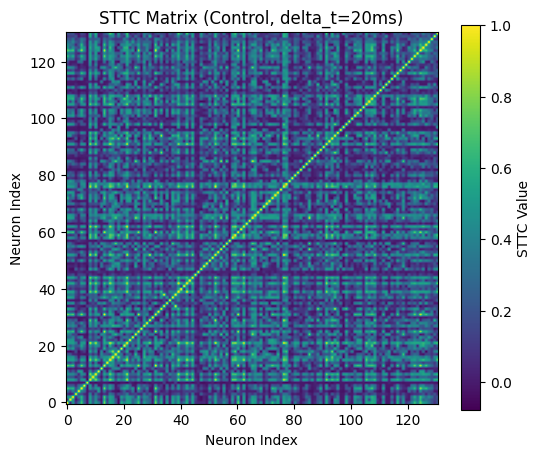

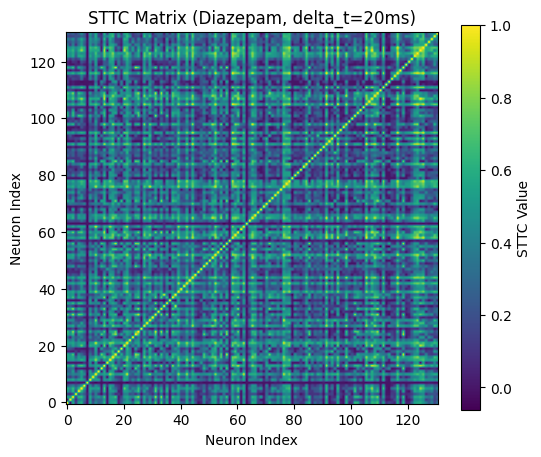

In [ ]:
from braingeneers.analysis.analysis import SpikeData # Make sure it's imported

import matplotlib.pyplot as plt
import numpy as np
# Assuming 'braingeneers' and 'SpikeData' are correctly imported
# Assuming 'data_control' and 'data_diazepam' SpikeData objects are loaded

# Define the time window delta_t in milliseconds
delta_t_ms = 20

try:
    # Calculate the STTC matrix using the SpikeData method
    sttc_matrix_control = data_control.spike_time_tilings()

    # Plot the matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(sttc_matrix_control, cmap='viridis', origin='lower')
    plt.title(f'STTC Matrix (Control, delta_t={delta_t_ms}ms)')
    plt.xlabel("Neuron Index")
    plt.ylabel("Neuron Index")
    plt.colorbar(label='STTC Value')
    plt.show()

except AttributeError:
    print("Error: The 'SpikeData' object does not have an 'sttc' method as assumed.")
    print("Please check the output of 'help(SpikeData)' for the correct method name.")
except Exception as e:
    print(f"An error occurred plotting STTC for control data: {e}")

# --- Plot STTC for Diazepam Dataset ---
try:
    # Calculate the STTC matrix using the SpikeData method
    sttc_matrix_diazepam = data_diazepam.spike_time_tilings()

    # Plot the matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(sttc_matrix_diazepam, cmap='viridis', origin='lower')
    plt.title(f'STTC Matrix (Diazepam, delta_t={delta_t_ms}ms)')
    plt.xlabel("Neuron Index")
    plt.ylabel("Neuron Index")
    plt.colorbar(label='STTC Value')
    plt.show()

except AttributeError:
    print("Error: The 'SpikeData' object does not have an 'sttc' method as assumed.")
    print("Please check the output of 'help(SpikeData)' for the correct method name.")
except Exception as e:
    print(f"An error occurred plotting STTC for diazepam data: {e}")


### Compare Plots (1.5 Points)

Compare the two plots of the STTC. Does the variation between these plots make sense, considering our understanding of diazepam? Explain. Is the comparison between these two plots consistent with the variation you see between the correlation matrices of both datasets?

<font color="green"><b>Answer

Yes, the variation makes sense. Diazepam decreases overall activity but increases uniformity of firing patterns often associated and seen in the raster plot for diazepam. These STTC graphs corresponds to the correlation graph for both datasets.


### Diagonal of STTC (1.5 Points)

What do the diagonal values of the STTC equal. Why is this the case?

<font color="green"><b>Answer

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from braingeneers.analysis.analysis import SpikeData # Assuming SpikeData is available

# --- Re-define or ensure these are loaded ---
# Helper function from source code
def mat_to_spikeData(mat_path):
    """Loads spike times from a .mat file into a SpikeData object."""
    mat = sio.loadmat(mat_path)
    # Adjusting for potential structure differences in .mat file
    try:
        # Try original structure from the source code notebook
         units = [i[0][0]*1e3 for i in mat['spike_times']]
    except (IndexError, TypeError):
         # Fallback or adjust based on actual structure inspection
         print(f"Warning: Could not unpack spike_times with original structure for {mat_path}. Adjust mat_to_spikeData if needed.")
         # Example alternative if it's just a list of arrays:
         units = [i*1e3 for i in mat['spike_times'].flatten()] # Flatten might be needed depending on shape
    sd = SpikeData(units)
    return sd

# Load the control data
try:
    control_file_path = '/home/jovyan/data/ephys/2023-08-28-e-Math_Mind_Class/HW2-Electrophysiology/Spike_Raster_Control.mat'
    data_control = mat_to_spikeData(control_file_path)
    control_data_loaded = True
    print("Control data loaded successfully.")
except FileNotFoundError:
    print(f"Error: Control data file not found at {control_file_path}.")
    control_data_loaded = False
except Exception as e:
    print(f"An error occurred loading the control data: {e}")
    control_data_loaded = False

# Load the diazepam data
try:
    diazepam_file_path = '/home/jovyan/data/ephys/2023-08-28-e-Math_Mind_Class/HW2-Electrophysiology/Spike_Raster_Diazepam.mat'
    data_diazepam = mat_to_spikeData(diazepam_file_path)
    diazepam_data_loaded = True
    print("Diazepam data loaded successfully.")
except FileNotFoundError:
    print(f"Error: Diazepam data file not found at {diazepam_file_path}.")
    diazepam_data_loaded = False
except Exception as e:
    print(f"An error occurred loading the diazepam data: {e}")
    diazepam_data_loaded = False


# Define the time window delta_t in milliseconds
delta_t_ms = 20

# --- Calculate STTC Matrix and Print Diagonal for CONTROL ---
if control_data_loaded:
    print("\n--- Control Dataset ---")
    try:
        # Calculate the STTC matrix using the SpikeData method
        sttc_matrix_control = data_control.spike_time_tilings()

        # Extract the diagonal elements
        diagonal_values_control = np.diag(sttc_matrix_control)

        # Print the diagonal values (or a subset if there are many neurons)
        print(f"Diagonal values of the STTC Matrix (Control, delta_t={delta_t_ms}ms):")
        if len(diagonal_values_control) > 20:
            print(diagonal_values_control[:10]) # Print first 10
            print("...")
            print(diagonal_values_control[-10:]) # Print last 10
        else:
            print(diagonal_values_control)

        # Verify if all diagonal values are close to 1
        all_ones_control = np.allclose(diagonal_values_control, 1.0)
        # print(f"\nAre all diagonal values approximately 1? {all_ones_control}")

        # print("\nWhy are they 1?")
        # print("The diagonal elements represent the STTC of each neuron's spike train with itself.")
        # print("By definition, a spike train is perfectly correlated with itself within the time window (delta_t), resulting in an STTC value of 1.")

    except AttributeError:
        print("Error: The 'SpikeData' object does not have an 'sttc' method as assumed.")
        print("Please check the output of 'help(SpikeData)' for the correct method name.")
    except Exception as e:
        print(f"An error occurred calculating or processing STTC for control data: {e}")
else:
    print("\nSkipping Control STTC calculation as data was not loaded.")


# --- Calculate STTC Matrix and Print Diagonal for DIAZEPAM ---
if diazepam_data_loaded:
    print("\n--- Diazepam Dataset ---")
    try:
        # Calculate the STTC matrix using the SpikeData method
        sttc_matrix_diazepam = data_diazepam.spike_time_tilings()

        # Extract the diagonal elements
        diagonal_values_diazepam = np.diag(sttc_matrix_diazepam)

        # Print the diagonal values (or a subset if there are many neurons)
        print(f"Diagonal values of the STTC Matrix (Diazepam, delta_t={delta_t_ms}ms):")
        if len(diagonal_values_diazepam) > 20:
            print(diagonal_values_diazepam[:10]) # Print first 10
            print("...")
            print(diagonal_values_diazepam[-10:]) # Print last 10
        else:
            print(diagonal_values_diazepam)

        # Verify if all diagonal values are close to 1
        all_ones_diazepam = np.allclose(diagonal_values_diazepam, 1.0)
        # print(f"\nAre all diagonal values approximately 1? {all_ones_diazepam}")

    except AttributeError:
        print("Error: The 'SpikeData' object does not have an 'sttc' method as assumed.")
        print("Please check the output of 'help(SpikeData)' for the correct method name.")
    except Exception as e:
        print(f"An error occurred calculating or processing STTC for diazepam data: {e}")
else:
    print("\nSkipping Diazepam STTC calculation as data was not loaded.")



Control data loaded successfully.
Diazepam data loaded successfully.

--- Control Dataset ---
Diagonal values of the STTC Matrix (Control, delta_t=20ms):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
...
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

--- Diazepam Dataset ---
Diagonal values of the STTC Matrix (Diazepam, delta_t=20ms):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
...
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The diagonal elements represent the STTC of each neuron's spike train with itself.
By definition, a spike train is perfectly correlated with itself within the time window (delta_t), resulting in an STTC value of 1.
